In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import accuracy_score, roc_auc_score

import lightgbm as lgb

import warnings
warnings.filterwarnings("ignore")

In [2]:
p = "/kaggle/input/competitions/playground-series-s6e3/"

df_train = pd.read_csv(p + "train.csv")
df_test = pd.read_csv(p + "test.csv")
df_submission = pd.read_csv(p + "sample_submission.csv")

In [3]:
print(df_train.shape)
print(df_test.shape)

(594194, 21)
(254655, 20)


In [4]:
df_train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [5]:
df_submission.head()

,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [7]:
df_train.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177262,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [8]:
# 欠損値の確認
print("=== train ===")
print(df_train.isnull().sum())
print()
print("=== test ===")
print(df_test.isnull().sum())

=== train ===
id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

=== test ===
id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64


In [9]:
numeric_cols = df_train.select_dtypes(include='number')
numeric_cols

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,0,29,60.10,1653.85
1,1,0,58,69.50,3778.20
2,2,0,58,100.40,5841.35
3,3,0,1,69.70,70.70
4,4,0,1,70.45,70.45
...,...,...,...,...,...
594189,594189,0,57,97.55,5460.70
594190,594190,0,72,91.95,6782.15
594191,594191,0,72,24.40,1871.90
594192,594192,0,32,86.00,2847.20


In [10]:
numeric_cols["tenure"] * numeric_cols["MonthlyCharges"]

0         1742.90
1         4031.00
2         5823.20
3           69.70
4           70.45
           ...   
594189    5560.35
594190    6620.40
594191    1756.80
594192    2752.00
594193     109.10
Length: 594194, dtype: float64

In [11]:
features = ["tenure", "MonthlyCharges"]
target = "Churn"


X_train = df_train[features]
y_train = df_train[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (594194, 2)
y_train: (594194,)


In [12]:
X_test = df_test[features]
print("X_test:", X_test.shape)

X_test: (254655, 2)


In [13]:
params = {
    "boosting_type": "gbdt",
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.1,
    "num_leaves": 31,
    "n_estimators": 100000,
    "random_state": 42,
    "importance_type": "gain",
    "verbosity": -1,
}

In [14]:
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

metrics = []
imp = pd.DataFrame()
models = []
test_preds = np.zeros(len(X_test)) 


for nfold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    print(f"\n========== Fold {nfold + 1} / {n_splits} ==========")

    x_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    x_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]

    model = lgb.LGBMClassifier(**params)
    model.fit(
        x_tr, y_tr,
        eval_set=[(x_va, y_va)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(0),
        ],
    )

    # 学習データ・検証データのスコア
    y_tr_pred = model.predict(x_tr)
    y_va_pred = model.predict(x_va)
    metric_tr = accuracy_score(y_tr, y_tr_pred)
    metric_va = accuracy_score(y_va, y_va_pred)
    print(f"[Accuracy] train: {metric_tr:.4f}, val: {metric_va:.4f}")

    metrics.append([nfold, metric_tr, metric_va])
    models.append(model)
    test_preds += model.predict_proba(X_test)[:, 1] / n_splits


    # 特徴量の重要度を記録
    _imp = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.feature_importances_,
        "fold": nfold,
    })
    imp = pd.concat([imp, _imp], axis=0, ignore_index=True)


========== Fold 1 / 5 ==========
[Accuracy] train: 0.8463, val: 0.8456

========== Fold 2 / 5 ==========
[Accuracy] train: 0.8461, val: 0.8454

========== Fold 3 / 5 ==========
[Accuracy] train: 0.8462, val: 0.8457

========== Fold 4 / 5 ==========
[Accuracy] train: 0.8462, val: 0.8453

========== Fold 5 / 5 ==========
[Accuracy] train: 0.8466, val: 0.8447


In [15]:
metrics = np.array(metrics)

print(f"[CV Result] train: {metrics[:, 1].mean():.4f} ± {metrics[:, 1].std():.4f}")
print(f"[CV Result] val:   {metrics[:, 2].mean():.4f} ± {metrics[:, 2].std():.4f}")

[CV Result] train: 0.8463 ± 0.0002
[CV Result] val:   0.8454 ± 0.0003


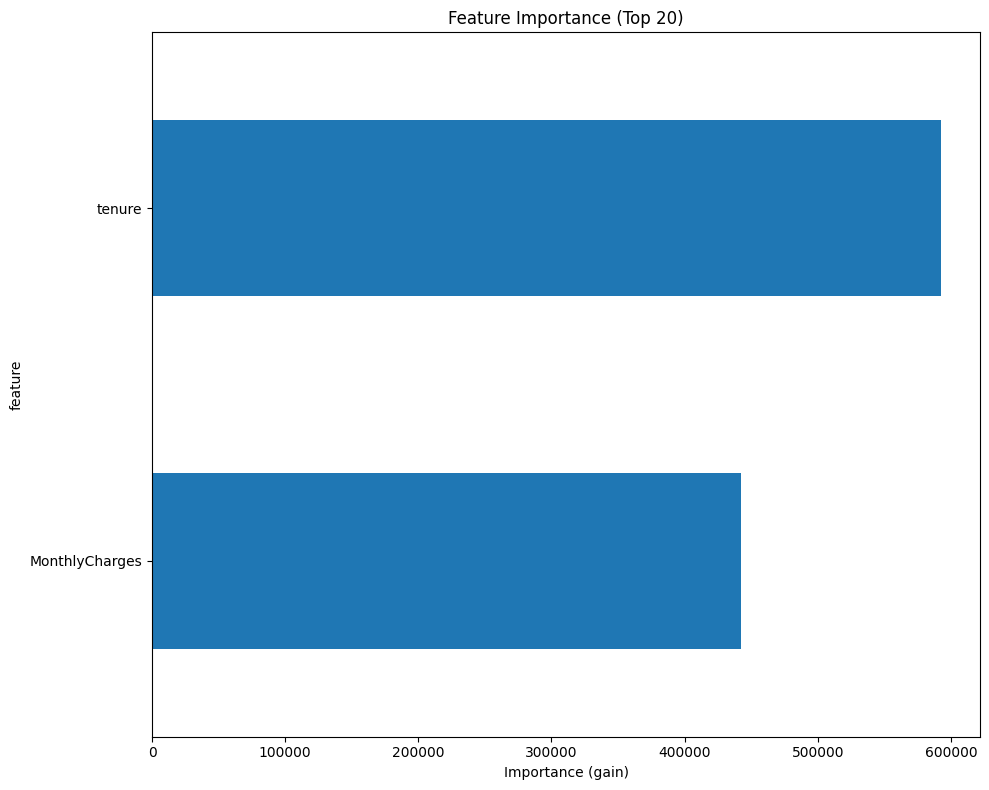

In [16]:
# 全foldの重要度を平均
imp_mean = imp.groupby("feature")["importance"].mean().sort_values(ascending=False)

# 上位20個をプロット
plt.figure(figsize=(10, 8))
imp_mean.head(20).plot(kind="barh")
plt.xlabel("Importance (gain)")
plt.title("Feature Importance (Top 20)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [17]:
df_submission

,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0
...,...,...
254650,848844,0
254651,848845,0
254652,848846,0
254653,848847,0


In [18]:
df_submission[target] = test_preds
df_submission.head()

,id,Churn
0,594194,0.019225
1,594195,0.000716
2,594196,0.124104
3,594197,0.009096
4,594198,0.631021


In [19]:
df_submission.to_csv("submission.csv", index=False)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb

import warnings
warnings.filterwarnings("ignore")

In [21]:
p = "/kaggle/input/competitions/playground-series-s6e3/"

df_train = pd.read_csv(p + "train.csv")
df_test = pd.read_csv(p + "test.csv")
df_submission = pd.read_csv(p + "sample_submission.csv")

In [22]:
print(df_train.shape)
print(df_test.shape)

(594194, 21)
(254655, 20)


In [23]:
df_train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [24]:
df_submission.head()

,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0


In [25]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [26]:
df_train.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177262,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [27]:
# 欠損値の確認
print("=== train ===")
print(df_train.isnull().sum())
print()
print("=== test ===")
print(df_test.isnull().sum())

=== train ===
id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

=== test ===
id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64


In [28]:
# カテゴリカラムの一覧
cat_cols = df_train.select_dtypes(include=["object", "string"]).columns.tolist()
cat_cols.remove("Churn")  # 目的変数は除外

print(f"カテゴリカラム数: {len(cat_cols)}")
print(cat_cols)

カテゴリカラム数: 15
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


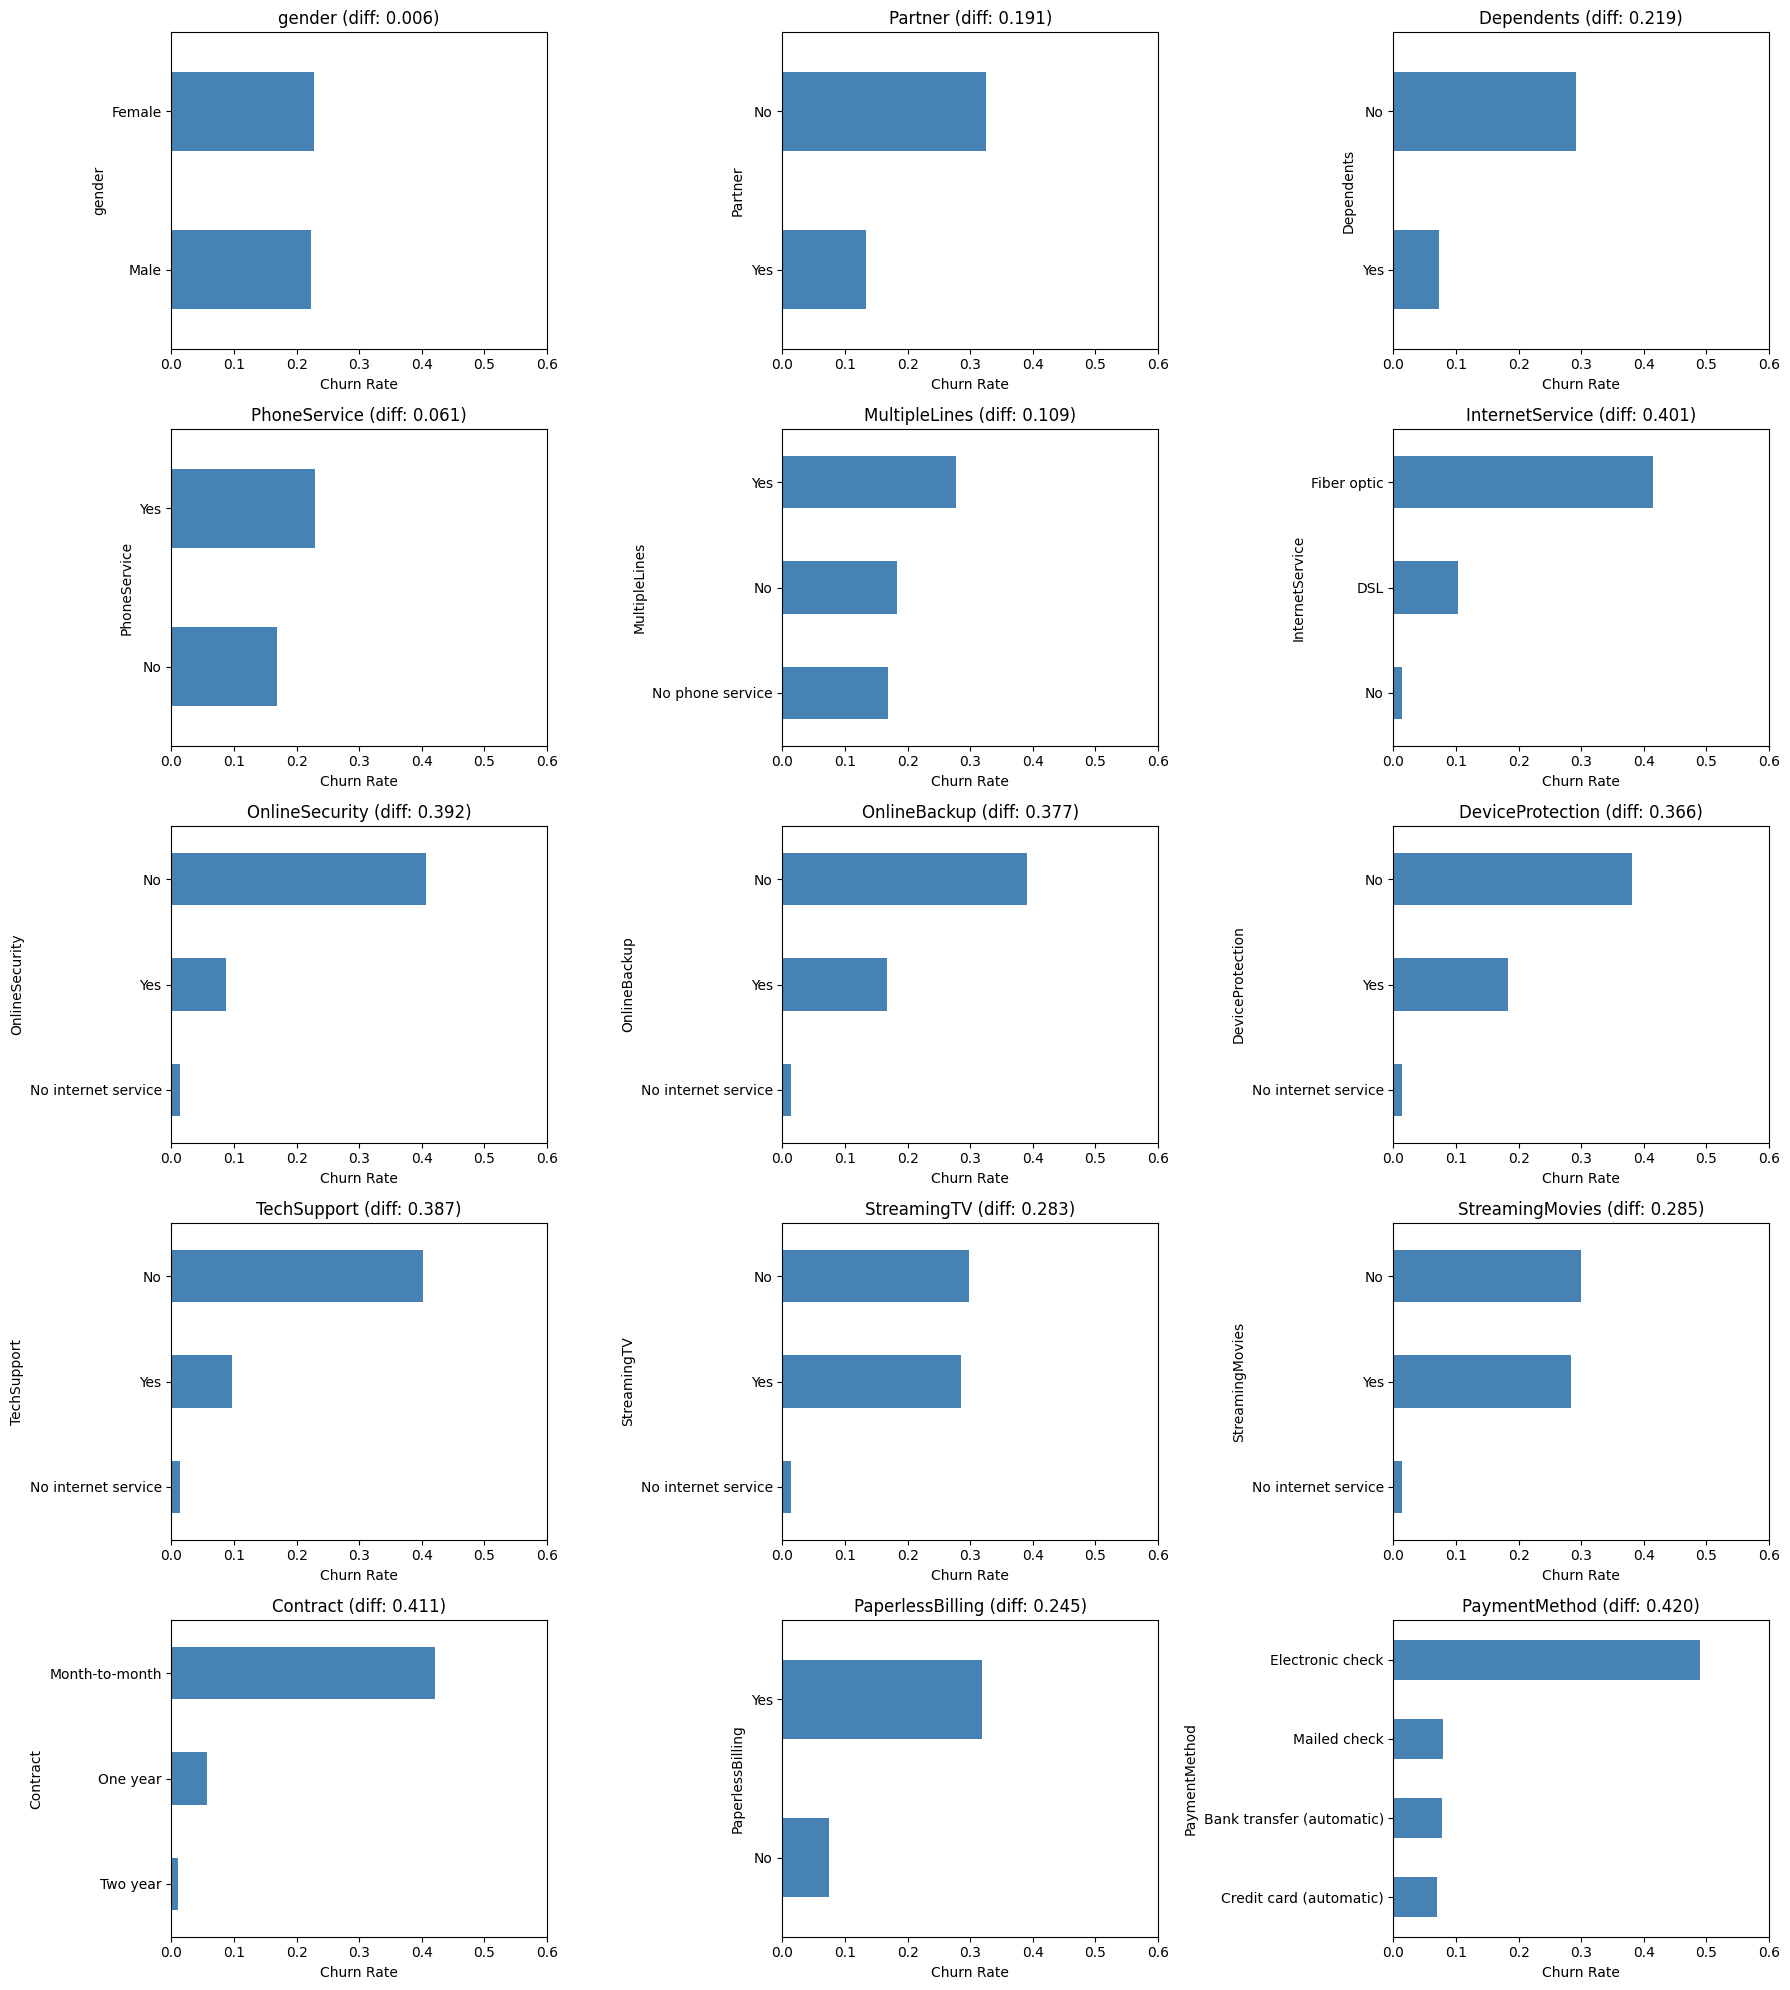

In [29]:
# 各カテゴリカラムについて、カテゴリ値ごとのChurn率を可視化する
fig, ax = plt.subplots(5, 3, figsize=(18, 20))
ax = ax.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df_train.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean())
    churn_rate.sort_values().plot(kind="barh", ax=ax[i], color="steelblue")
    ax[i].set_title(f"{col} (diff: {churn_rate.max() - churn_rate.min():.3f})")
    ax[i].set_xlabel("Churn Rate")
    ax[i].set_xlim(0, 0.6)

plt.tight_layout()
plt.show()

In [30]:
# Churn率の差が大きい順にランキングする
churn_diff = {}
for col in cat_cols:
    churn_rate = df_train.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean())
    churn_diff[col] = churn_rate.max() - churn_rate.min()

churn_diff_sorted = sorted(churn_diff.items(), key=lambda x: -x[1])

print("=== Churn率の差ランキング ===")
for rank, (col, diff) in enumerate(churn_diff_sorted, 1):
    print(f"{rank}. {col}: {diff:.4f}")

=== Churn率の差ランキング ===
1. PaymentMethod: 0.4197
2. Contract: 0.4106
3. InternetService: 0.4011
4. OnlineSecurity: 0.3918
5. TechSupport: 0.3873
6. OnlineBackup: 0.3767
7. DeviceProtection: 0.3663
8. StreamingMovies: 0.2850
9. StreamingTV: 0.2831
10. PaperlessBilling: 0.2448
11. Dependents: 0.2186
12. Partner: 0.1908
13. MultipleLines: 0.1089
14. PhoneService: 0.0608
15. gender: 0.0057


In [31]:
# 追加するカテゴリカラム
add_cat_cols = ["PaymentMethod", "Contract"]

# LabelEncodingを適用する
label_encoders = {}
for col in add_cat_cols:
    le = LabelEncoder()
    le.fit(pd.concat([df_train[col], df_test[col]]))
    label_encoders[col] = le

    print(f"=== {col} ===")
    for cls, label in zip(le.classes_, le.transform(le.classes_)):
        print(f"  {cls} -> {label}")
    print()

=== PaymentMethod ===
  Bank transfer (automatic) -> 0
  Credit card (automatic) -> 1
  Electronic check -> 2
  Mailed check -> 3

=== Contract ===
  Month-to-month -> 0
  One year -> 1
  Two year -> 2



In [32]:
# ベースラインの2特徴量 + カテゴリ特徴量2つ = 合計4特徴量
features = ["tenure", "MonthlyCharges"] + add_cat_cols
target = "Churn"

# train/testにLabelEncoding結果を格納
for col in add_cat_cols:
    df_train[col] = label_encoders[col].transform(df_train[col])
    df_test[col] = label_encoders[col].transform(df_test[col])

X_train = df_train[features]
y_train = df_train[target]

X_test = df_test[features]

print(f"features: {features}")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

features: ['tenure', 'MonthlyCharges', 'PaymentMethod', 'Contract']
X_train: (594194, 4)
X_test:  (254655, 4)


In [33]:
params = {
    "boosting_type": "gbdt",
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.1,
    "num_leaves": 31,
    "n_estimators": 100000,
    "random_state": 42,
    "importance_type": "gain",
    "verbosity": -1,
}

In [34]:
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

metrics = []
imp = pd.DataFrame()
models = []
test_preds = np.zeros(len(X_test)) 


for nfold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    print(f"\n========== Fold {nfold + 1} / {n_splits} ==========")

    x_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    x_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]

    model = lgb.LGBMClassifier(**params)
    model.fit(
        x_tr, y_tr,
        eval_set=[(x_va, y_va)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(0),
        ],
    )

# 学習データ・検証データのスコア
    y_tr_pred = model.predict(x_tr)
    y_va_pred = model.predict(x_va)
    metric_tr = accuracy_score(y_tr, y_tr_pred)
    metric_va = accuracy_score(y_va, y_va_pred)
    print(f"[Accuracy] train: {metric_tr:.4f}, val: {metric_va:.4f}")

    metrics.append([nfold, metric_tr, metric_va])
    models.append(model)
    test_preds += model.predict_proba(X_test)[:, 1] / n_splits


    # 特徴量の重要度を記録
    _imp = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.feature_importances_,
        "fold": nfold,
    })
    imp = pd.concat([imp, _imp], axis=0, ignore_index=True)


========== Fold 1 / 5 ==========
[Accuracy] train: 0.8539, val: 0.8522

========== Fold 2 / 5 ==========
[Accuracy] train: 0.8533, val: 0.8523

========== Fold 3 / 5 ==========
[Accuracy] train: 0.8536, val: 0.8532

========== Fold 4 / 5 ==========
[Accuracy] train: 0.8534, val: 0.8535

========== Fold 5 / 5 ==========
[Accuracy] train: 0.8535, val: 0.8524


In [35]:
metrics = np.array(metrics)

print(f"[CV Result] train: {metrics[:, 1].mean():.4f} ± {metrics[:, 1].std():.4f}")
print(f"[CV Result] val:   {metrics[:, 2].mean():.4f} ± {metrics[:, 2].std():.4f}")

[CV Result] train: 0.8535 ± 0.0002
[CV Result] val:   0.8527 ± 0.0005


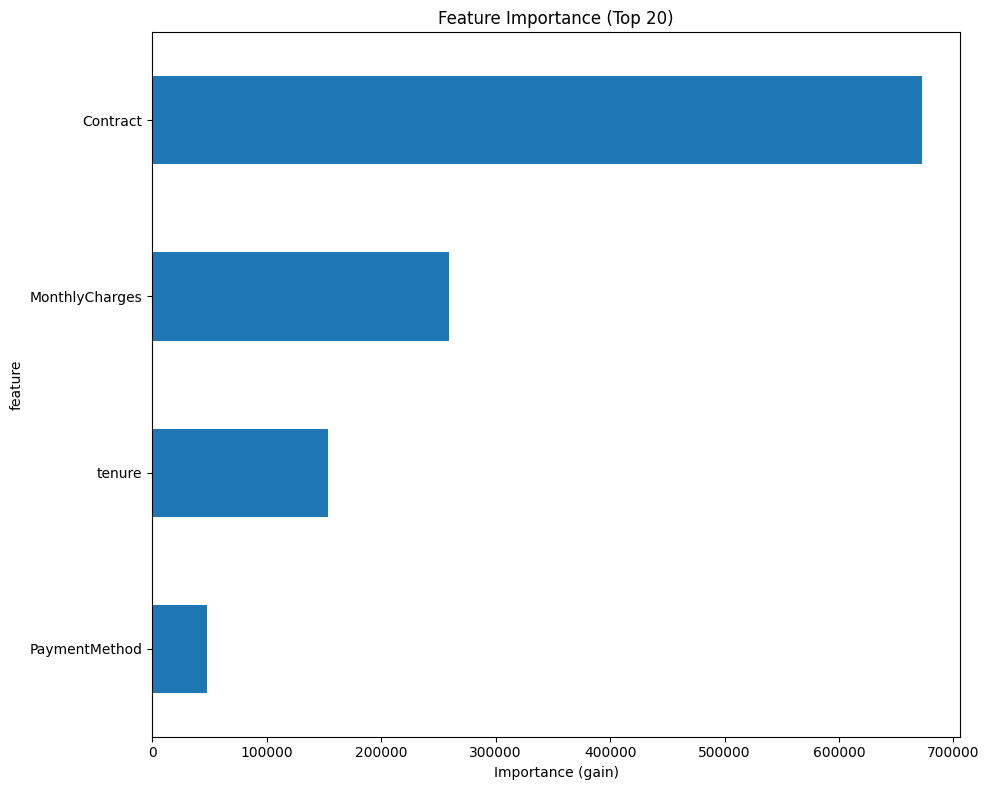

In [36]:
# 全foldの重要度を平均
imp_mean = imp.groupby("feature")["importance"].mean().sort_values(ascending=False)

# 上位20個をプロット
plt.figure(figsize=(10, 8))
imp_mean.head(20).plot(kind="barh")
plt.xlabel("Importance (gain)")
plt.title("Feature Importance (Top 20)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [37]:
df_submission

,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0
...,...,...
254650,848844,0
254651,848845,0
254652,848846,0
254653,848847,0


In [38]:
df_submission[target] = test_preds
df_submission.head()

,id,Churn
0,594194,0.047543
1,594195,0.000834
2,594196,0.110856
3,594197,0.004677
4,594198,0.668820


In [39]:
df_submission.to_csv("submission.csv", index=False)